# 04 - Ridership (raw annual base)

Builds the general per-line annual ridership base from SEPTA's public per-station and system-wide monthly datasets. Fetches, cleans, and imputes values for missing years.

Saves two small artifacts consumed by `04b_ridership_safe.ipynb`:
- `4_ridership_annual_by_line.parquet` -- `line`, `year`, `avg_daily_boards` (2017-2024; 2025 has no real
  per-line survey and isn't estimated here at all -- `04b` builds a leak-free YTD-ratio estimate for it)
- `4_ridership_monthly_index_fallback.parquet` -- `ref_year`, `ref_month`, `monthly_index`
  (whole-year-normalized, used only as `04b`'s pre-2019 fallback, since no real trailing data exists that
  far back)

Possible future addition: monthly ridership *lags* (trailing trend, mirroring the lateness-lag features
built in `07`) -- not built yet.

## Fetch raw ridership data

Two SEPTA/OpenDataPhilly datasets: 
1) system-wide monthly ridership by mode (2019-present, via `utils.fetch_ridership_monthly()`, used here to scale imputed years), and
2) per-station Regional Rail ridership (2017-2024 w/ missing years 2018, 2020, and 2021).

In [1]:
import ssl
import urllib.request
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import fetch_ridership_monthly

BASEPATH = "../data"

# station-level fetch
_SYSTEM_CERT_PATH = "/etc/ssl/cert.pem"
_ctx = (
    ssl.create_default_context(cafile = _SYSTEM_CERT_PATH)
    if os.path.exists(_SYSTEM_CERT_PATH) else ssl.create_default_context()
)

rr_monthly_raw = fetch_ridership_monthly()
print(f"system-wide monthly dataset: {rr_monthly_raw.shape}, "
      f"{rr_monthly_raw['ref_year'].min()}-{rr_monthly_raw['ref_year'].max()}")

system-wide monthly dataset: (87, 3), 2019-2026


## Build per-line annual ridership base

Per-station Regional Rail ridership, service-day-weighted ((5x weekday + Saturday + Sunday) / 7) up to line-year averages. 

A few line-name mismatches against the GTFS-linked OTP data need reconciling first:
- `Trunk` is the shared Center City corridor, not attributable to an individual line - dropped here
- a one-off `Manyunk/Norristown` typo in the 2024 release, and 
- `Bala Cynwyd` (OTP's `Cynwyd`). 
- `Media/Wawa` is backfilled to all years in this dataset even though OTP shows `Media/Elwyn` before the August 2022 rename - left as-is here and reconciled via `line_key()` in `04b` instead, same as everywhere else in project.

In [2]:
RIDERSHIP_URL = "https://hub.arcgis.com/api/v3/datasets/281807e0099f461c8ae3db9ef4347970_0/downloads/data?format=csv&spatialRefId=3857&where=1%3D1"

with urllib.request.urlopen(RIDERSHIP_URL, context = _ctx, timeout = 30) as resp:
    df_rider = pd.read_csv(resp)
print(f"station-level ridership: {df_rider.shape}")

df_rider.columns = df_rider.columns.str.strip().str.lower()
df_rider.to_csv(f"{BASEPATH}/4_ridership_by_station.csv", index = False)

# drop GIS artifacts, not needed here
df_rider = df_rider.drop(columns = ["x", "y", "fid"]).reset_index(drop = True)

# check line-name alignment against the GTFS-linked OTP data before 
# aggregating (single-column read to avoid re-read of full dataset)
otp_lines = set(
    pd.read_parquet(f"{BASEPATH}/2_df_gtfs_linked.parquet", columns = ["line"])["line"].dropna().unique()
)
ridership_lines = set(df_rider["line"].unique())
print("Before remap -- in OTP, not in ridership:", otp_lines - ridership_lines)
print("Before remap -- in ridership, not in OTP:", ridership_lines - otp_lines)

line_remap = {"Manyunk/Norristown": "Manayunk/Norristown", "Bala Cynwyd": "Cynwyd"}
df_rider["line"] = df_rider["line"].replace(line_remap)
df_rider = df_rider[df_rider["line"] != "Trunk"].copy()

ridership_lines = set(df_rider["line"].unique())
# expect exactly {'Media/Elwyn', 'Center City Only Trains'} here, neither fixable by a
# ridership-side remap: 'Media/Elwyn' has a real ridership match under a different name
# ('Media/Wawa', backfilled to all years in this dataset) -- reconciled downstream via
# line_key() collapsing both to 'Media'. 'Center City Only Trains' has no ridership analog at
# all -- it's a pseudo-line (trains that never leave the Center City trunk) dropped entirely in
# 07_reduce_for_modeling.ipynb's final polish patches, not reconciled here.
print("After remap -- in OTP, not in ridership (expect {'Media/Elwyn', 'Center City Only Trains'}):",
      otp_lines - ridership_lines)
print("After remap -- in ridership, not in OTP (expect empty -- Trunk dropped, "
      "Manyunk/Norristown + Bala Cynwyd renamed):", ridership_lines - otp_lines)

service_wts = {"Weekday": 5 / 7, "Saturday": 1 / 7, "Sunday": 1 / 7}
df_rider["boards_wtd"] = df_rider["boards"] * df_rider["service_ty"].map(service_wts)
df_rider_line = (
    df_rider.groupby(["line", "year"], as_index = False)
    .agg(avg_daily_boards = ("boards_wtd", "sum"))
)
print(f"\nline-year rows (pre-imputation): {df_rider_line.shape}")

station-level ridership: (5235, 14)


Before remap -- in OTP, not in ridership: {'Center City Only Trains', 'Media/Elwyn'}
Before remap -- in ridership, not in OTP: {'Trunk', 'Manyunk/Norristown', 'Bala Cynwyd'}
After remap -- in OTP, not in ridership (expect {'Media/Elwyn', 'Center City Only Trains'}): {'Center City Only Trains', 'Media/Elwyn'}
After remap -- in ridership, not in OTP (expect empty -- Trunk dropped, Manyunk/Norristown + Bala Cynwyd renamed): set()

line-year rows (pre-imputation): (65, 3)


## Impute missing years (2018, 2020, 2021)

The station-level survey covers 2017, 2019, 2022, 2023, 2024 only. Missing years are estimated from the
already-fetched system-wide monthly totals. Full picture, year by year:

| Year | Annual ridership figure |
|------|--------|
| 2017 | Observed |
| 2018 | Interpolated (avg of 2017 + 2019 observed line-level values) |
| 2019 | Observed |
| 2020 | 2022 line shares x observed system-wide ratio |
| 2021 | 2022 line shares x observed system-wide ratio |
| 2022 | Observed |
| 2023 | Observed |
| 2024 | Observed |
| 2025 | *not estimated here -- see `04b_ridership_safe.ipynb`* |

2022 (not 2019) is used as the reference year for scaling 2020/2021: 2022 still reflects some Covid disruption, whereas 2019 had much higher pre-pandemic ridership totals.

In [3]:
rr_totals = rr_monthly_raw.groupby("ref_year")["ridership"].mean()

r_2017 = df_rider_line[df_rider_line["year"] == 2017].set_index("line")["avg_daily_boards"]
r_2019 = df_rider_line[df_rider_line["year"] == 2019].set_index("line")["avg_daily_boards"]
r_2018 = ((r_2017 + r_2019) / 2).reset_index()
r_2018["year"] = 2018
estimated_rows = [r_2018]

scale_map = {2020: 2022, 2021: 2022}
for yr, ref_yr in scale_map.items():
    rows = df_rider_line[df_rider_line["year"] == ref_yr].copy()
    rows["year"] = yr
    rows["avg_daily_boards"] = rows["avg_daily_boards"] * (rr_totals[yr] / rr_totals[ref_yr])
    estimated_rows.append(rows)

df_rider_line = (
    pd.concat([df_rider_line] + estimated_rows, ignore_index = True)
    .sort_values(["line", "year"])
    .reset_index(drop = True)
)
print(f"line-year rows (all years): {df_rider_line.shape}")
print(sorted(df_rider_line['year'].unique()))

line-year rows (all years): (104, 3)
[np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## Build whole-year monthly index (pre-2019 fallback only)

Whole-year normalization (`month's ridership / that year's mean`), used only as the fallback for
reference months before the public monthly dataset's 2019 start (2017, 2018), since no actual trailing data can be computed that far back.

2017/2018 don't appear in the monthly dataset at all, so their monthly shape is estimated as the average
of "normal" (non-Covid) observed years - validated below.

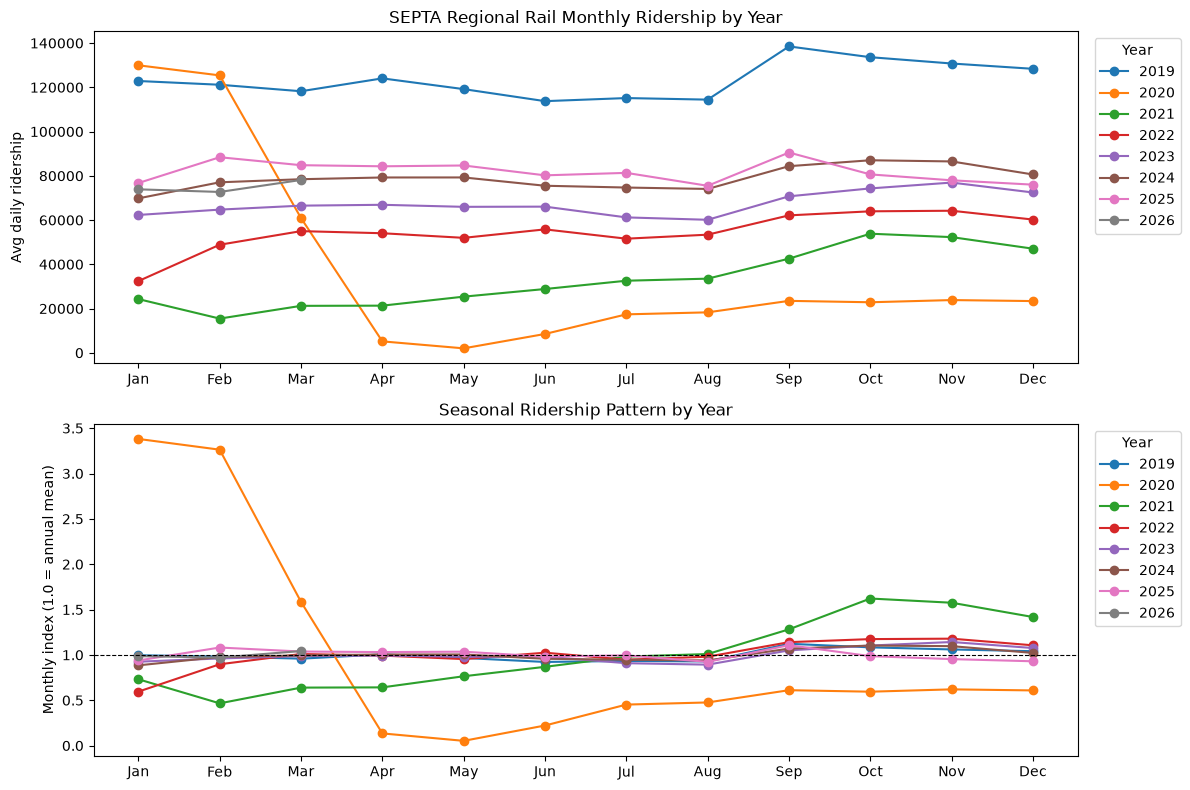

In [4]:
fig, axes = plt.subplots(2, 1, figsize = (12, 8))

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# raw monthly ridership by year
for yr, grp in rr_monthly_raw.groupby("ref_year"):
    axes[0].plot(grp["ref_month"], grp["ridership"], marker = "o", label = str(yr))
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].set_ylabel("Avg daily ridership")
axes[0].set_title("SEPTA Regional Rail Monthly Ridership by Year")
axes[0].legend(title = "Year", bbox_to_anchor = (1.01, 1), loc = "upper left")

# monthly index (month / that year's mean) to isolate the seasonal shape from the raw level
_check = rr_monthly_raw.copy()
_check["annual_mean"] = _check.groupby("ref_year")["ridership"].transform("mean")
_check["monthly_index"] = _check["ridership"] / _check["annual_mean"]

for yr, grp in _check.groupby("ref_year"):
    axes[1].plot(grp["ref_month"], grp["monthly_index"], marker = "o", label = str(yr))
axes[1].axhline(1.0, color = "black", linestyle = "--", linewidth = 0.8)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].set_ylabel("Monthly index (1.0 = annual mean)")
axes[1].set_title("Seasonal Ridership Pattern by Year")
axes[1].legend(title = "Year", bbox_to_anchor = (1.01, 1), loc = "upper left")

plt.tight_layout()
plt.show()
del _check

Observations:

- "Normal" years (2019, 2022-2025) cluster tightly around the 1.0 baseline index with modest seasonal variation. This suggests we can use their average as a proxy for 2017 and 2018's seasonal patterns since they have no monthly data available.
    - 2022 shows slightly more month-to-month variability than other years in this group, but its seasonal shape is consistent with the rest of the cluster, so I retain it in our average below.
- 2020's dramatic Jan - May collapse reflects the Covid shutdown.
- We see a distinct upward trend across 2021, starting well below the annual mean in early months and climbing above it by the end of the year. For this reason, it's not included in the "normal" year range.

In [5]:
rr_monthly_full = rr_monthly_raw.copy()
rr_monthly_full["annual_mean"] = rr_monthly_full.groupby("ref_year")["ridership"].transform("mean")
rr_monthly_full["monthly_index"] = rr_monthly_full["ridership"] / rr_monthly_full["annual_mean"]

monthly_index_original = rr_monthly_full[["ref_year", "ref_month", "monthly_index"]].copy()

# 2017/2018: avg seasonal pattern from non-Covid years
# (excludes 2020/2021's heavy pandemic skew)
normal_years = [2019, 2022, 2023, 2024, 2025]
normal_index = (
    monthly_index_original[monthly_index_original["ref_year"].isin(normal_years)]
    .groupby("ref_month", as_index = False)
    .agg(monthly_index = ("monthly_index", "mean"))
)
imputed_rows = []
for yr in [2017, 2018]:
    rows = normal_index.copy()
    rows["ref_year"] = yr
    imputed_rows.append(rows)

monthly_index_original = (
    pd.concat([monthly_index_original] + imputed_rows, ignore_index = True)
    .sort_values(["ref_year", "ref_month"])
    .reset_index(drop = True)
)
print(f"whole-year monthly index rows: {monthly_index_original.shape}")

whole-year monthly index rows: (111, 3)


## Save

In [6]:
df_rider_line.to_parquet(f"{BASEPATH}/4_ridership_annual_by_line.parquet", index = False)
monthly_index_original.to_parquet(f"{BASEPATH}/4_ridership_monthly_index_fallback.parquet", index = False)
print(f"Saved {len(df_rider_line):,} rows to 4_ridership_annual_by_line.parquet")
print(f"Saved {len(monthly_index_original):,} rows to 4_ridership_monthly_index_fallback.parquet")

Saved 104 rows to 4_ridership_annual_by_line.parquet
Saved 111 rows to 4_ridership_monthly_index_fallback.parquet
